   age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  \
0   50       2     168    62.0    110     80            1     1      0     0   
1   55       1     156    85.0    140     90            3     1      0     0   
2   51       1     165    64.0    130     70            3     1      0     0   
3   48       2     169    82.0    150    100            1     1      0     0   
4   47       1     156    56.0    100     60            1     1      0     0   

   active  cardio        BMI  pulse_pressure  
0       1       0  21.967120              30  
1       1       1  34.927679              50  
2       0       1  23.507805              60  
3       1       1  28.710479              50  
4       0       0  23.011177              40  
<class 'pandas.core.frame.DataFrame'>
Index: 68621 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             68621 non-null  int64 

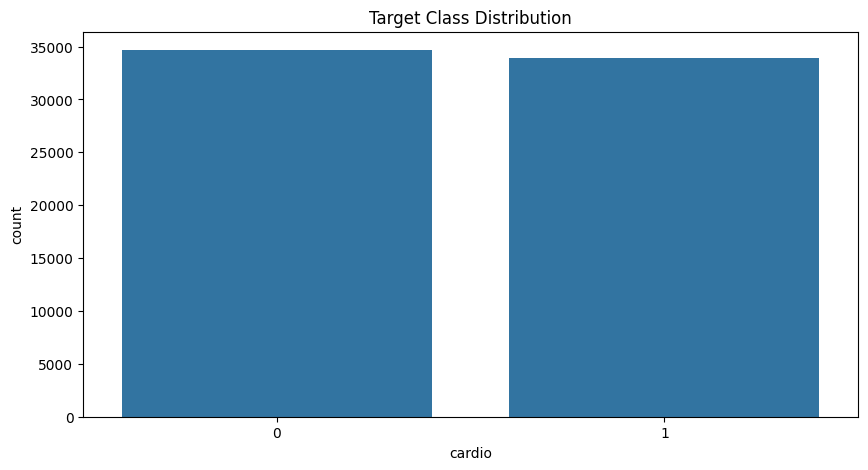

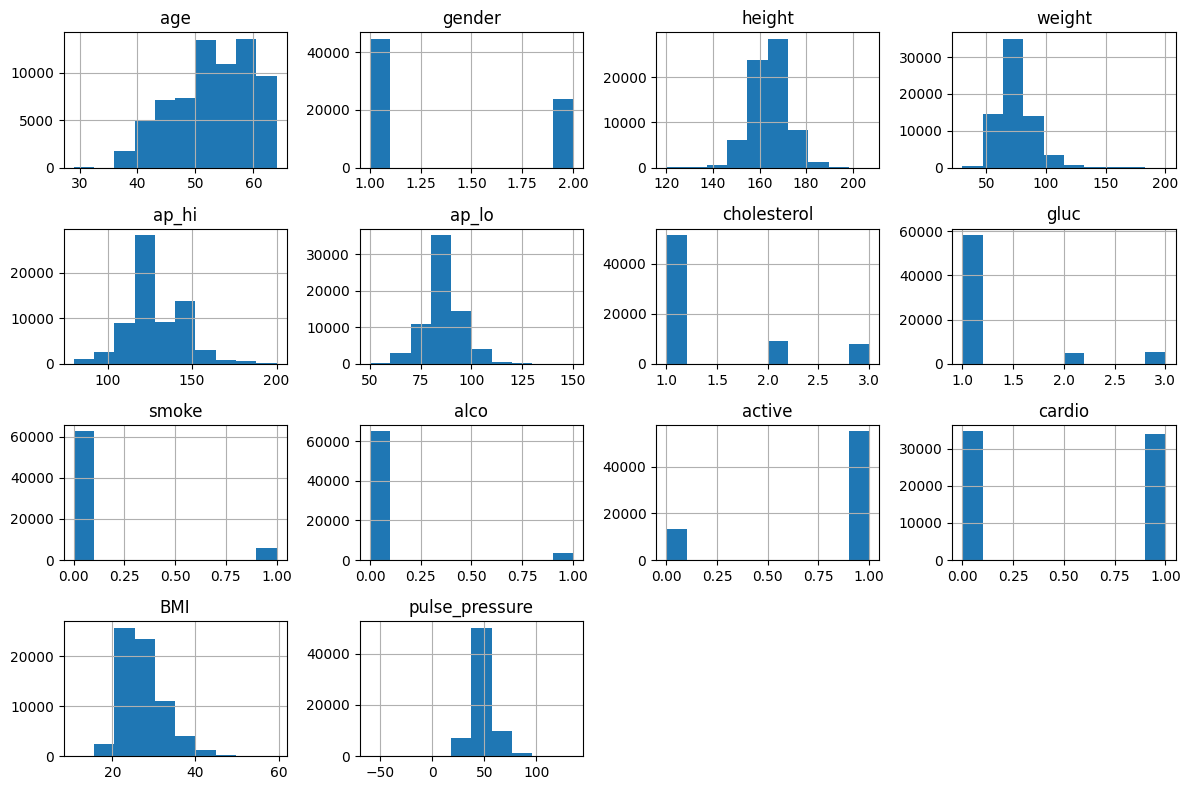

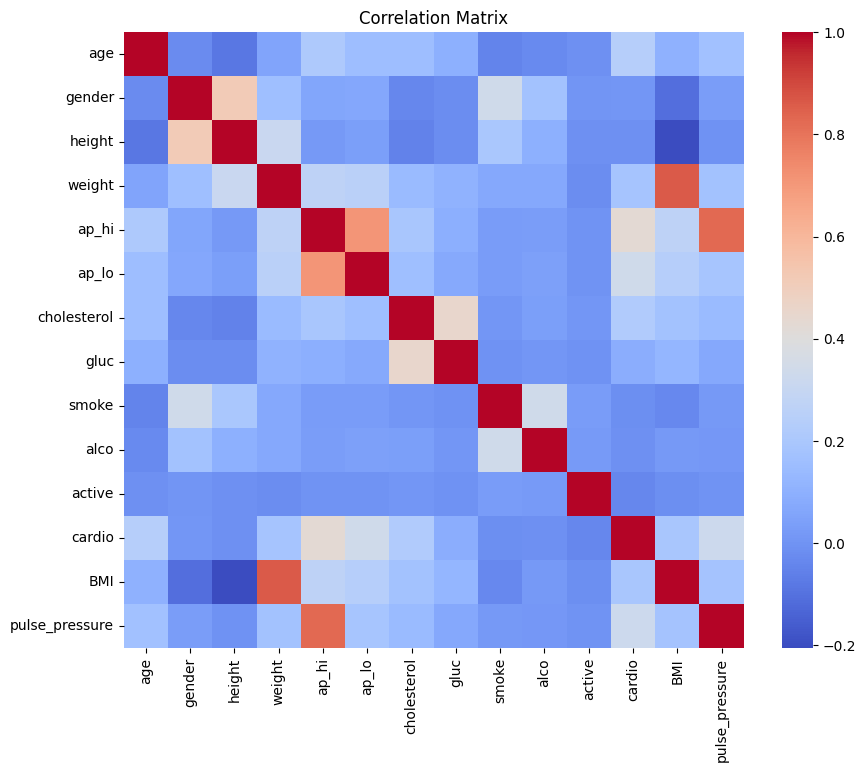


Model Accuracies:
Random Forest: 72.86%
SVM: 72.72%
Decision Tree: 72.60%
Logistic Regression: 72.15%
KNN: 70.89%

Best Model: Random Forest (72.86%)

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6933
           1       0.76      0.67      0.71      6786

    accuracy                           0.73     13719
   macro avg       0.73      0.73      0.73     13719
weighted avg       0.73      0.73      0.73     13719



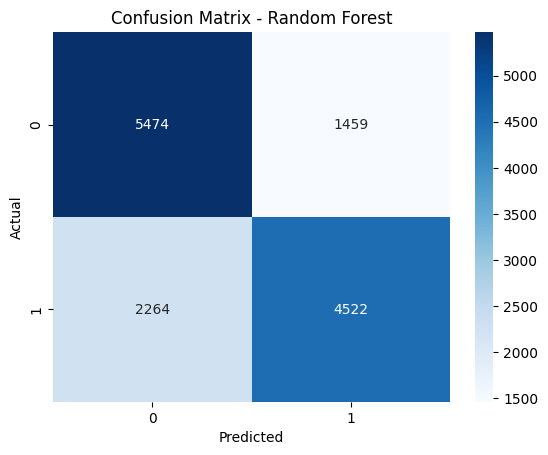

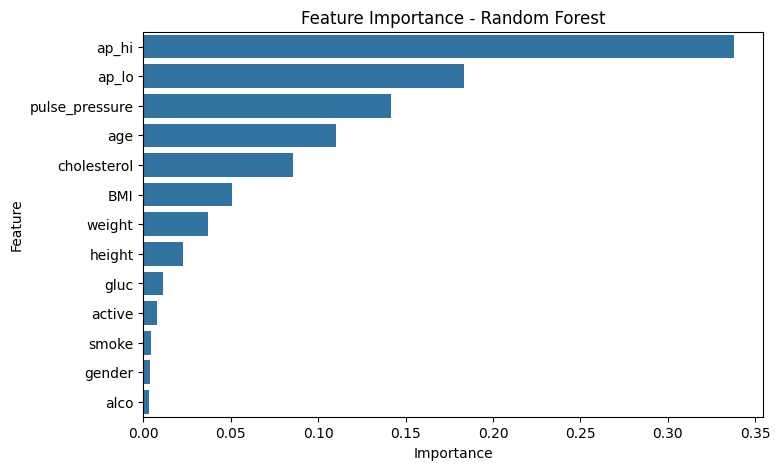

In [ ]:
# Cardiovascular Disease Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Load dataset
df = pd.read_csv("cardio_train.csv", sep=";")

# 2. Preprocessing
df['age'] = (df['age'] / 365).astype(int)
df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df.drop(columns=['id'], inplace=True)

# 3. Remove physiologically impossible values
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 200)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 150)]
df = df[(df['BMI'] >= 10) & (df['BMI'] <= 60)]

# 4. Basic info ---
print(df.head())
print(df.info())
print(df['cardio'].value_counts())

# 5. Feature engineering: BMI
df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)

# 6. Optional: remove physiologically impossible values
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 200)]
df = df[(df['ap_lo'] >= 50) & (df['ap_lo'] <= 150)]
df = df[(df['height'] >= 120) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

# 7. EDA ---
plt.figure(figsize=(10,5))
sns.countplot(x='cardio', data=df)
plt.title("Target Class Distribution")
plt.show()

# 8. Histograms for numeric features
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()


# 9. Correlation Matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 10. Prepare data
X = df.drop(columns=['cardio'])
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 11. Scale only for non-tree models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}

# 12. Logistic Regression
lr = LogisticRegression(max_iter=1000, solver='liblinear')
lr.fit(X_train_scaled, y_train)
results['Logistic Regression'] = accuracy_score(y_test, lr.predict(X_test_scaled))

# 13. KNN (tuned)
knn_params = {'n_neighbors': [5, 7, 9], 'weights': ['uniform', 'distance']}
knn = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3, scoring='accuracy', n_jobs=-1)
knn.fit(X_train_scaled, y_train)
results['KNN'] = accuracy_score(y_test, knn.predict(X_test_scaled))

# 14. Decision Tree (tuned)
dt_params = {'max_depth': [5, 10, 15, None], 'min_samples_split': [2, 5, 10]}
dt = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=3, scoring='accuracy', n_jobs=-1)
dt.fit(X_train, y_train)
results['Decision Tree'] = accuracy_score(y_test, dt.predict(X_test))

# 15. Random Forest (tuned)
rf_params = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf.fit(X_train, y_train)
results['Random Forest'] = accuracy_score(y_test, rf.predict(X_test))

# 16. SVM (tuned)
svm_params = {'C': [0.5, 1, 2], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']}
svm = GridSearchCV(SVC(), svm_params, cv=3, scoring='accuracy', n_jobs=-1)
svm.fit(X_train_scaled, y_train)
results['SVM'] = accuracy_score(y_test, svm.predict(X_test_scaled))

# 17. Print accuracies
print("\nModel Accuracies:")
for model, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model}: {acc*100:.2f}%")

# 18. Best Model Report
best_model_name = max(results, key=results.get)
print(f"\nBest Model: {best_model_name} ({results[best_model_name]*100:.2f}%)")

if best_model_name == 'Random Forest':
    best_model = rf.best_estimator_
    y_pred = rf.predict(X_test)
elif best_model_name == 'SVM':
    best_model = svm.best_estimator_
    y_pred = svm.predict(X_test_scaled)
elif best_model_name == 'KNN':
    best_model = knn.best_estimator_
    y_pred = knn.predict(X_test_scaled)
elif best_model_name == 'Logistic Regression':
    best_model = lr
    y_pred = lr.predict(X_test_scaled)
else:
    best_model = dt.best_estimator_
    y_pred = dt.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 19. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 20. Feature Importance (if tree-based)
if best_model_name in ['Random Forest', 'Decision Tree']:
    importances = best_model.feature_importances_
    feat_df = pd.DataFrame({"Feature": X.columns, "Importance": importances})
    feat_df.sort_values("Importance", ascending=False, inplace=True)

    plt.figure(figsize=(8,5))
    sns.barplot(x="Importance", y="Feature", data=feat_df)
    plt.title(f"Feature Importance - {best_model_name}")
    plt.show()
